
    Скачайте материалы к занятию.
    Проанализируйте 6 временных рядов из папки Series и сделайте их стационарными:
        monthly-sales-of-company-x-jan-6.csv
        monthly-boston-armed-robberies-j.csv
        international-airline-passengers.csv
        mean-monthly-air-temperature-deg.csv
        weekly-closings-of-the-dowjones-.csv
        daily-total-female-births-in-cal.csv
    Пришлите решение в виде ссылки на GitHub с ноутбуком.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller

In [2]:
data_monthly_sales_of_company = pd.read_csv('/home/slava/Documents/netology_ML/Временные ряды/1._Лекция_tsml/monthly-sales-of-company-x-jan-6.csv')
data_monthly_sales_of_company.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   77 non-null     object
 1   Count   77 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ KB


In [3]:
data_monthly_sales_of_company.head()

,Month,Count
0,1965-01,154
1,1965-02,96
2,1965-03,73
3,1965-04,49
4,1965-05,36


In [ ]:
data_monthly_sales_of_company['Month'] = pd.to_datetime(data_monthly_sales_of_company['Month'])
data_monthly_sales_of_company.set_index('Month', inplace=True)
data_monthly_sales_of_company.sort_index(inplace=True)

In [14]:
data_monthly_sales_of_company.head()

,Count
Month,
1965-01-01,154
1965-02-01,96
1965-03-01,73
1965-04-01,49
1965-05-01,36


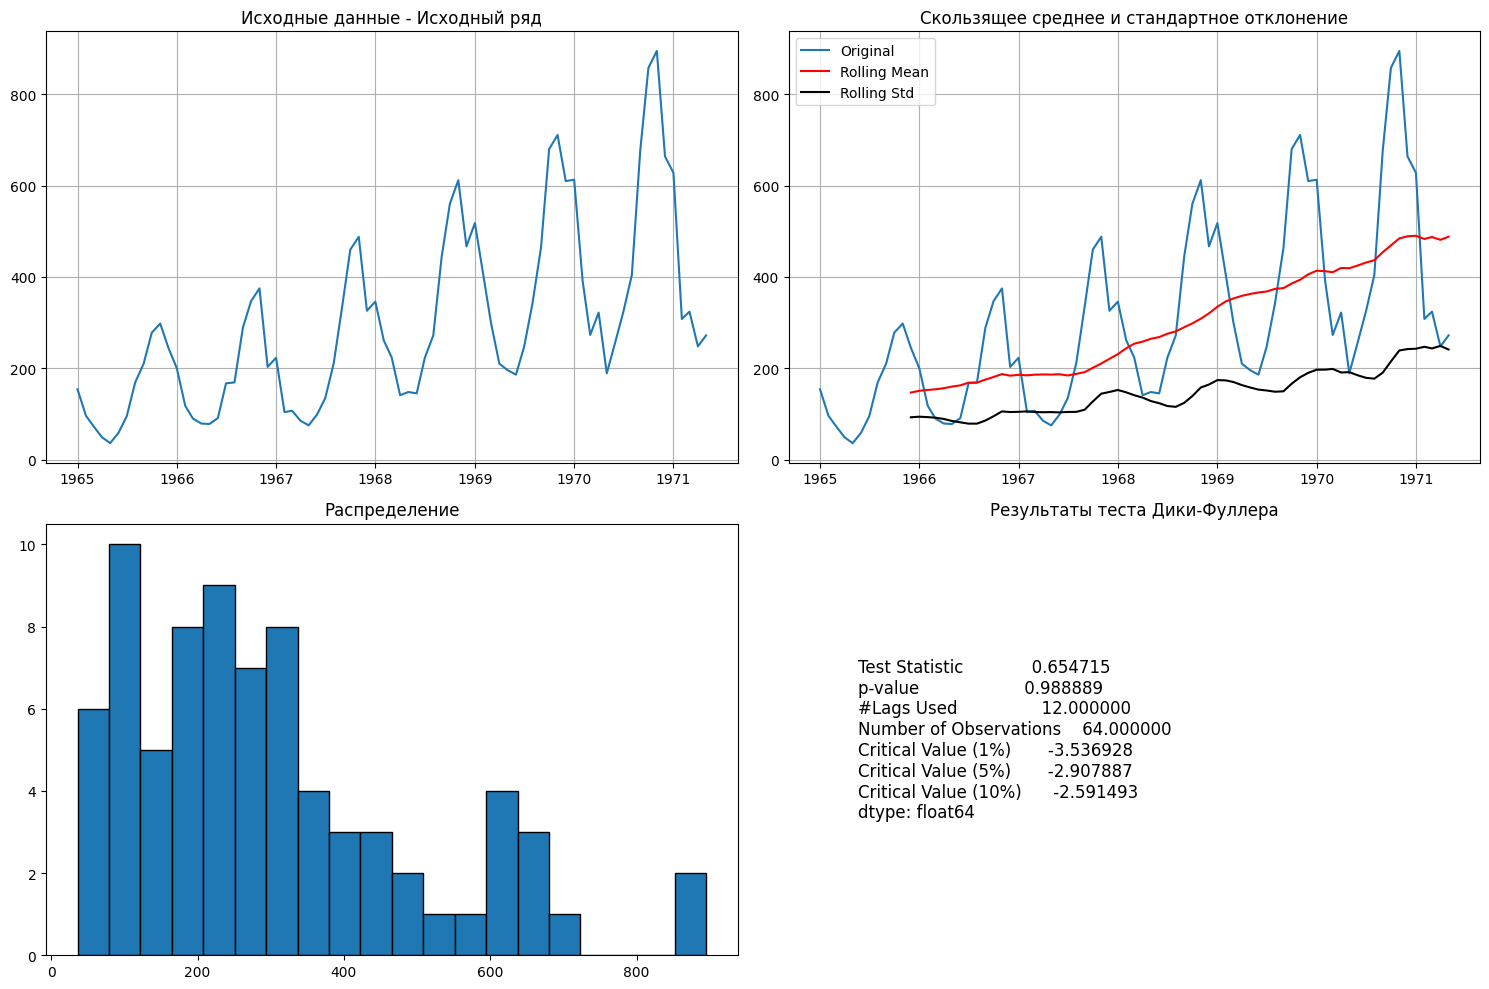


Результаты теста Дики-Фуллера:
Test Statistic             0.654715
p-value                    0.988889
#Lags Used                12.000000
Number of Observations    64.000000
Critical Value (1%)       -3.536928
Critical Value (5%)       -2.907887
Critical Value (10%)      -2.591493
dtype: float64

❌ p-value (0.9889) > 0.05 - Ряд НЕ стационарен


In [15]:
def check_stationarity(timeseries, title):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    axes[0, 0].plot(timeseries)
    axes[0, 0].set_title(f'{title} - Исходный ряд')
    axes[0, 0].grid(True)
    
    rolmean = timeseries.rolling(window=12).mean()
    rolstd = timeseries.rolling(window=12).std()
    
    axes[0, 1].plot(timeseries, label='Original')
    axes[0, 1].plot(rolmean, color='red', label='Rolling Mean')
    axes[0, 1].plot(rolstd, color='black', label='Rolling Std')
    axes[0, 1].set_title('Скользящее среднее и стандартное отклонение')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    axes[1, 0].hist(timeseries, bins=20, edgecolor='black')
    axes[1, 0].set_title('Распределение')
    
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], 
                        index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations'])
    
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    
    axes[1, 1].axis('off')
    axes[1, 1].text(0.1, 0.5, str(dfoutput), fontsize=12, verticalalignment='center')
    axes[1, 1].set_title('Результаты теста Дики-Фуллера')
    
    plt.tight_layout()
    plt.show()
    
    print("\nРезультаты теста Дики-Фуллера:")
    print(dfoutput)
    
    if dftest[1] <= 0.05:
        print(f"\n✅ p-value ({dftest[1]:.4f}) <= 0.05 - Ряд стационарен")
    else:
        print(f"\n❌ p-value ({dftest[1]:.4f}) > 0.05 - Ряд НЕ стационарен")
    
    return dftest[1]

p_value_original = check_stationarity(data_monthly_sales_of_company['Count'], 'Исходные данные')

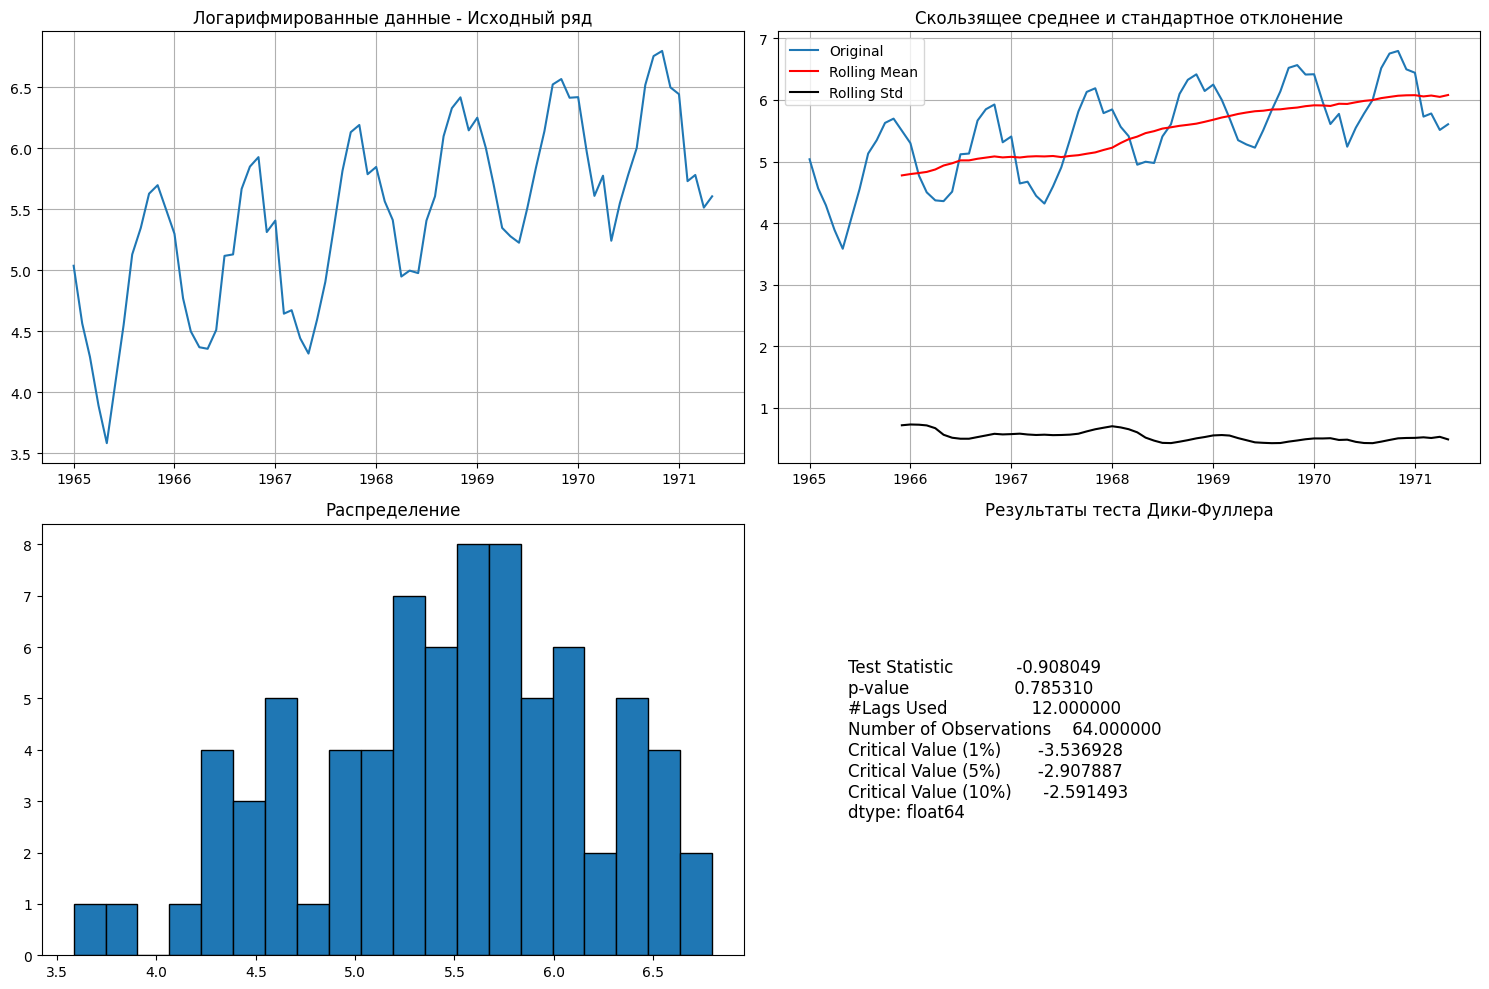


Результаты теста Дики-Фуллера:
Test Statistic            -0.908049
p-value                    0.785310
#Lags Used                12.000000
Number of Observations    64.000000
Critical Value (1%)       -3.536928
Critical Value (5%)       -2.907887
Critical Value (10%)      -2.591493
dtype: float64

❌ p-value (0.7853) > 0.05 - Ряд НЕ стационарен


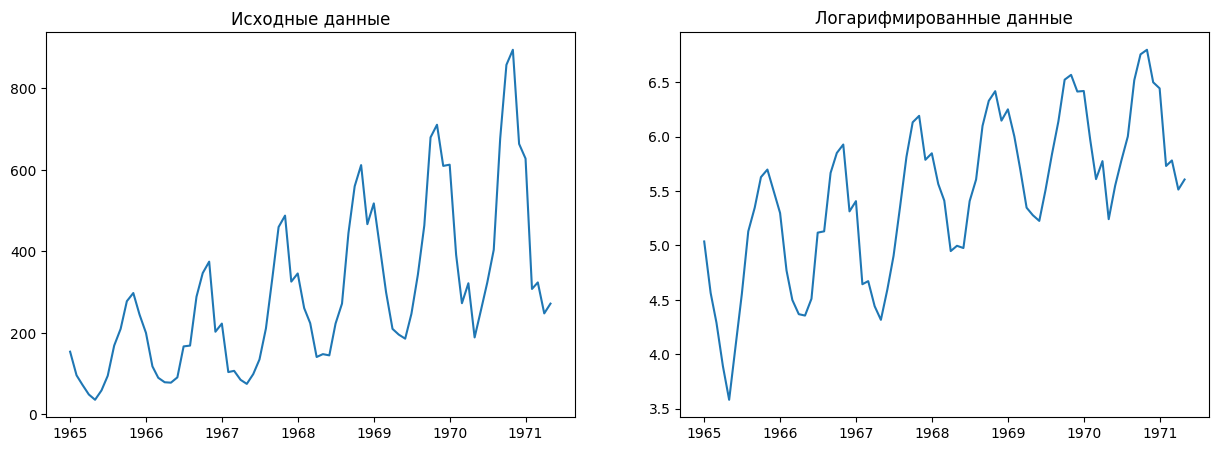

In [18]:
data_monthly_sales_of_company['Count_log'] = np.log(data_monthly_sales_of_company['Count'])

p_value_log = check_stationarity(data_monthly_sales_of_company['Count_log'], 'Логарифмированные данные')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(data_monthly_sales_of_company.index, data_monthly_sales_of_company['Count'])
axes[0].set_title('Исходные данные')
axes[1].plot(data_monthly_sales_of_company.index, data_monthly_sales_of_company['Count_log'])
axes[1].set_title('Логарифмированные данные')
plt.show()

## Выводы применения логорифмирования:
Почти не дало результат! Нужно пробовать другие методы.

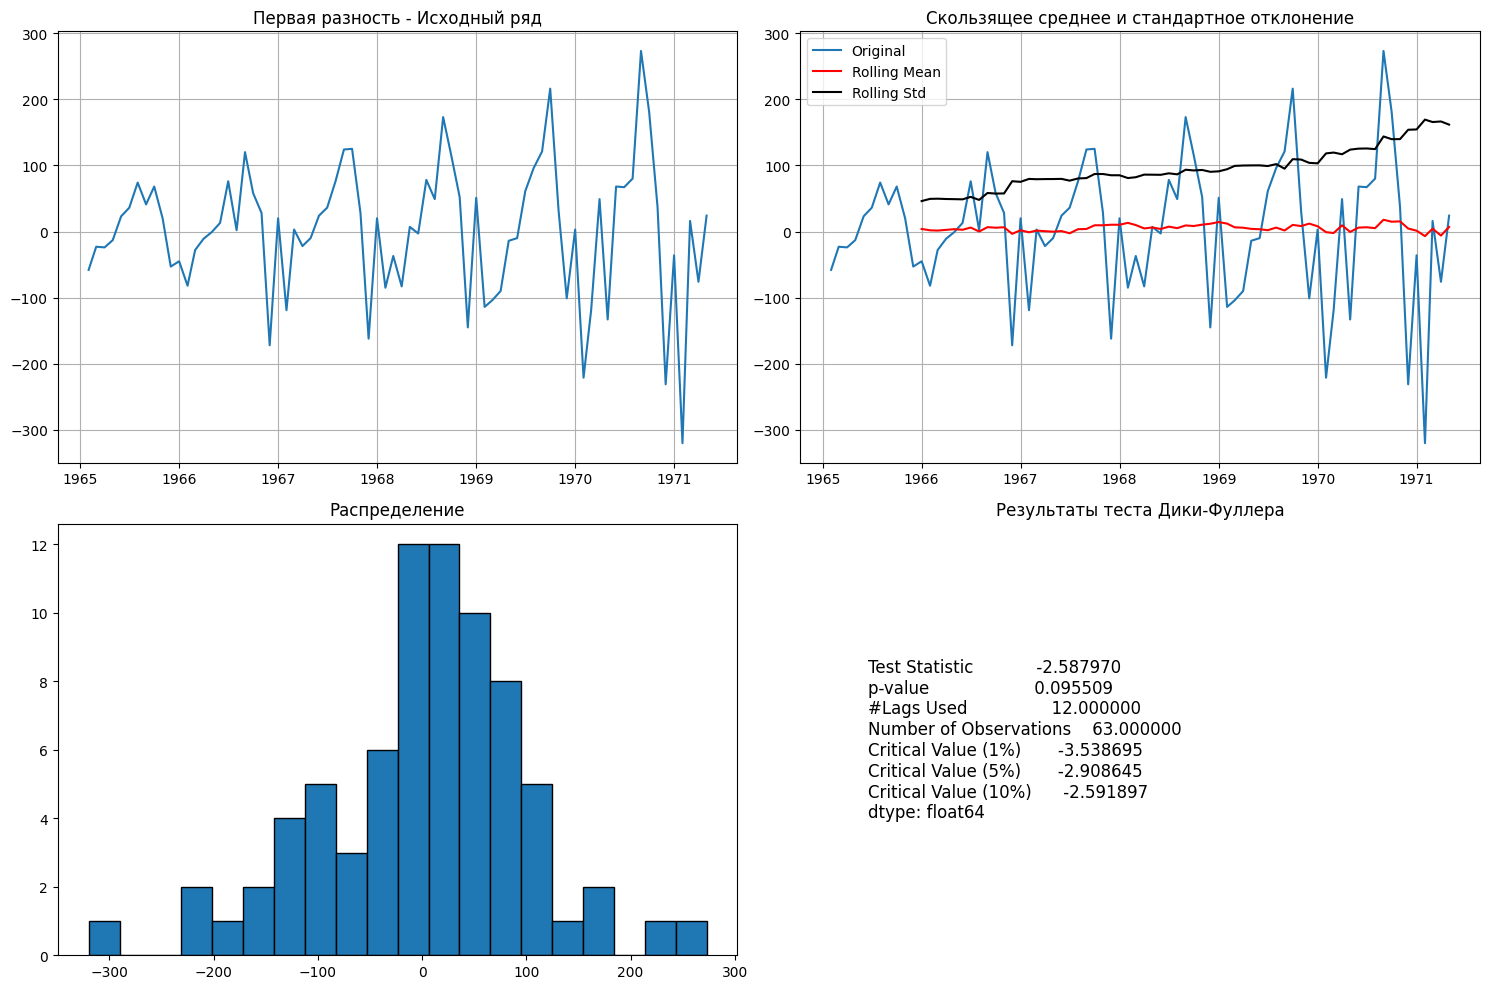


Результаты теста Дики-Фуллера:
Test Statistic            -2.587970
p-value                    0.095509
#Lags Used                12.000000
Number of Observations    63.000000
Critical Value (1%)       -3.538695
Critical Value (5%)       -2.908645
Critical Value (10%)      -2.591897
dtype: float64

❌ p-value (0.0955) > 0.05 - Ряд НЕ стационарен


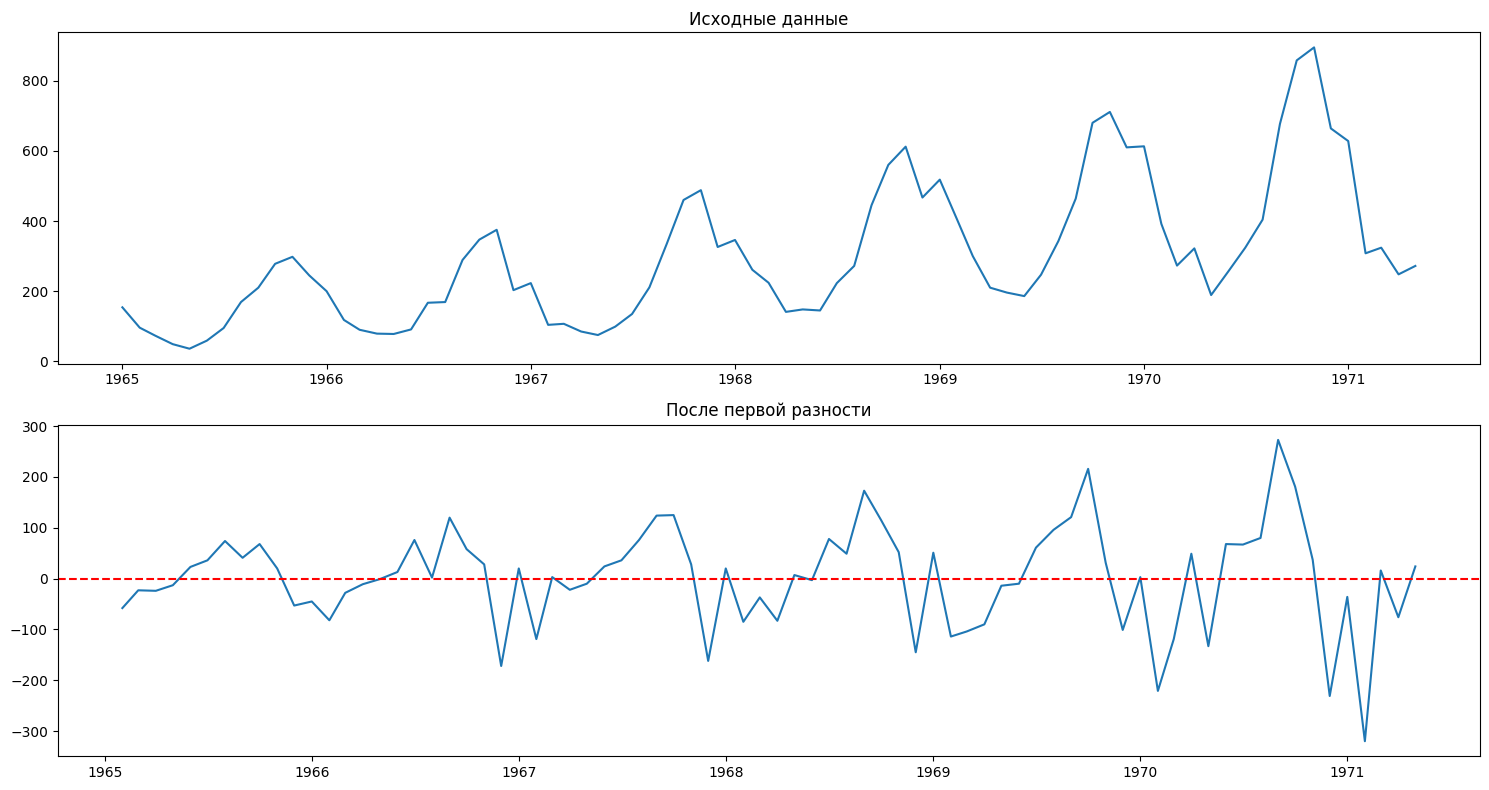

In [19]:
data_monthly_sales_of_company['Count_diff_1'] = data_monthly_sales_of_company['Count'].diff()

data_monthly_sales_of_company['Count_diff_1'].dropna(inplace=True)

p_value_diff1 = check_stationarity(data_monthly_sales_of_company['Count_diff_1'], 'Первая разность')

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(data_monthly_sales_of_company.index, data_monthly_sales_of_company['Count'])
axes[0].set_title('Исходные данные')
axes[1].plot(data_monthly_sales_of_company.index[1:], data_monthly_sales_of_company['Count_diff_1'].dropna())
axes[1].set_title('После первой разности')
axes[1].axhline(y=0, color='r', linestyle='--')
plt.tight_layout()
plt.show()

## Выводы применения Первая разность:
Дало результат, но не достаточно! Нужно пробовать другие методы.

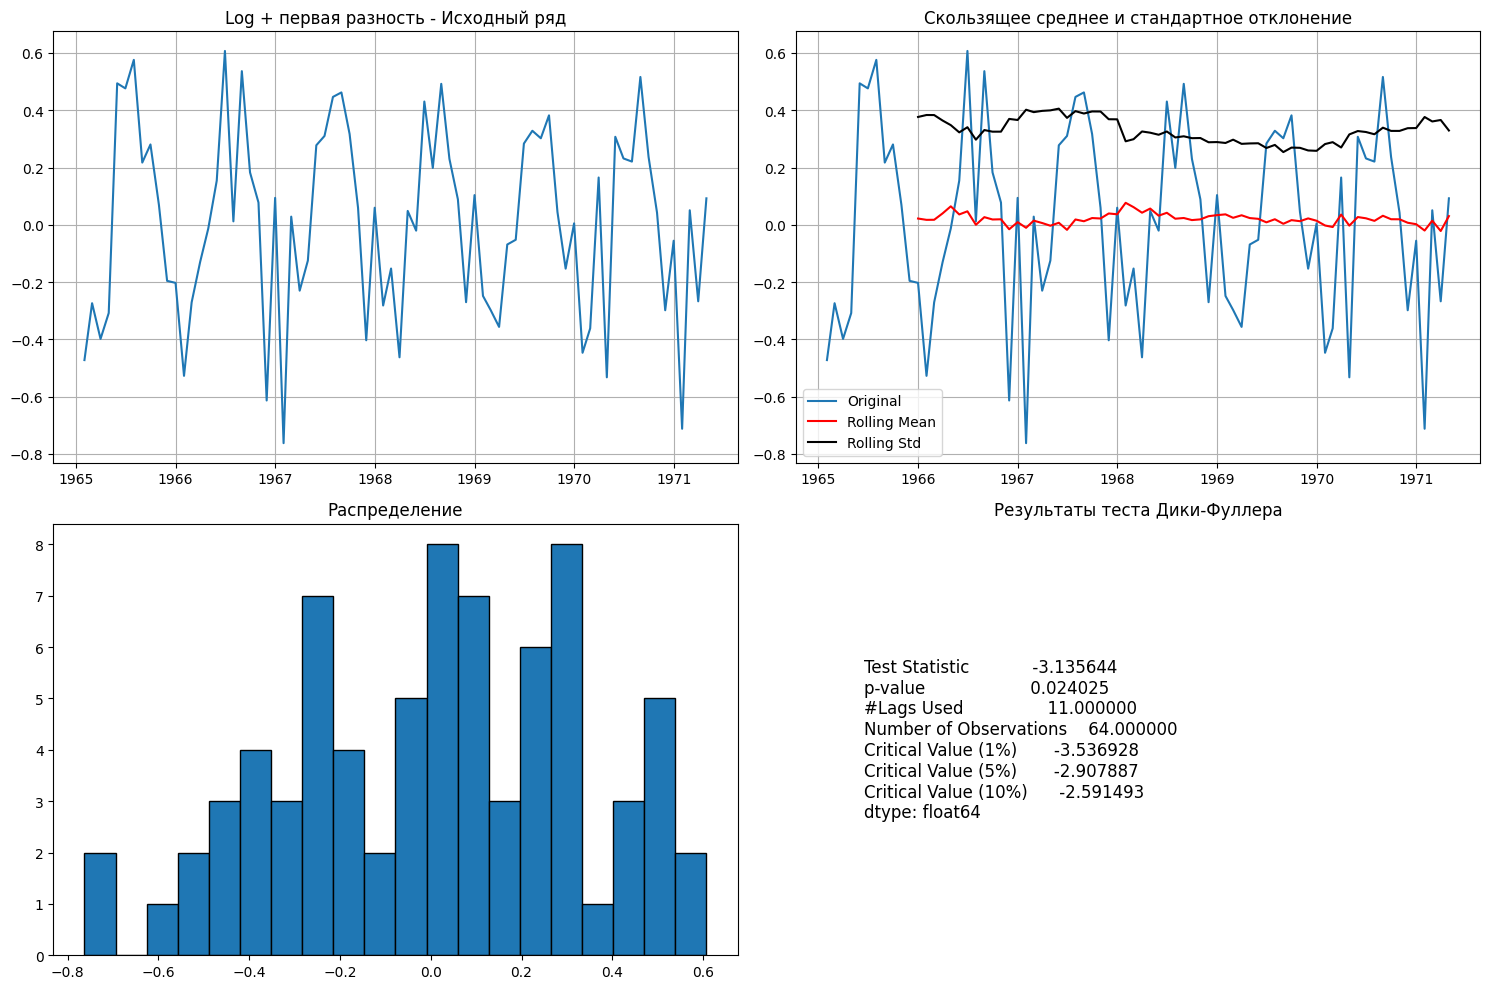


Результаты теста Дики-Фуллера:
Test Statistic            -3.135644
p-value                    0.024025
#Lags Used                11.000000
Number of Observations    64.000000
Critical Value (1%)       -3.536928
Critical Value (5%)       -2.907887
Critical Value (10%)      -2.591493
dtype: float64

✅ p-value (0.0240) <= 0.05 - Ряд стационарен


0.024025392839875176

In [27]:
data_monthly_sales_of_company['Count_log_diff'] = data_monthly_sales_of_company['Count_log'].diff()
check_stationarity(data_monthly_sales_of_company['Count_log_diff'], 'Log + первая разность')

In [22]:
data_monthly_sales_of_company.describe()

,Count,Count_log,Count_diff_1,Count_log_diff,Count_log_seasonal
count,77.000000,77.000000,76.000000,76.000000,65.000000
mean,298.402597,5.466231,1.552632,0.007485,0.241073
std,198.430570,0.721249,99.885854,0.327753,0.233325
min,36.000000,3.583519,-320.000000,-0.762781,-0.261123
25%,148.000000,4.997212,-47.000000,-0.268087,0.108854
50%,257.000000,5.549076,14.500000,0.046516,0.231928
75%,392.000000,5.971262,58.750000,0.247108,0.377787
max,895.000000,6.796824,273.000000,0.607134,0.920130


## Выводы применения Логарифм + первая разность:
Логарифм + первая разность дало результат!

In [23]:
data_monthly_boston = pd.read_csv('/home/slava/Documents/netology_ML/Временные ряды/1._Лекция_tsml/Series/monthly-boston-armed-robberies-j.csv')
data_monthly_boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   118 non-null    object
 1   Count   118 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.0+ KB


In [25]:
data_monthly_boston.describe()

,Count
count,118.000000
mean,196.288136
std,128.043602
min,29.000000
25%,85.500000
50%,166.000000
75%,296.750000
max,500.000000


In [ ]:
data_monthly_boston['Month'] = pd.to_datetime(data_monthly_boston['Month'])
data_monthly_boston.set_index('Month', inplace=True)
data_monthly_boston.sort_index(inplace=True)

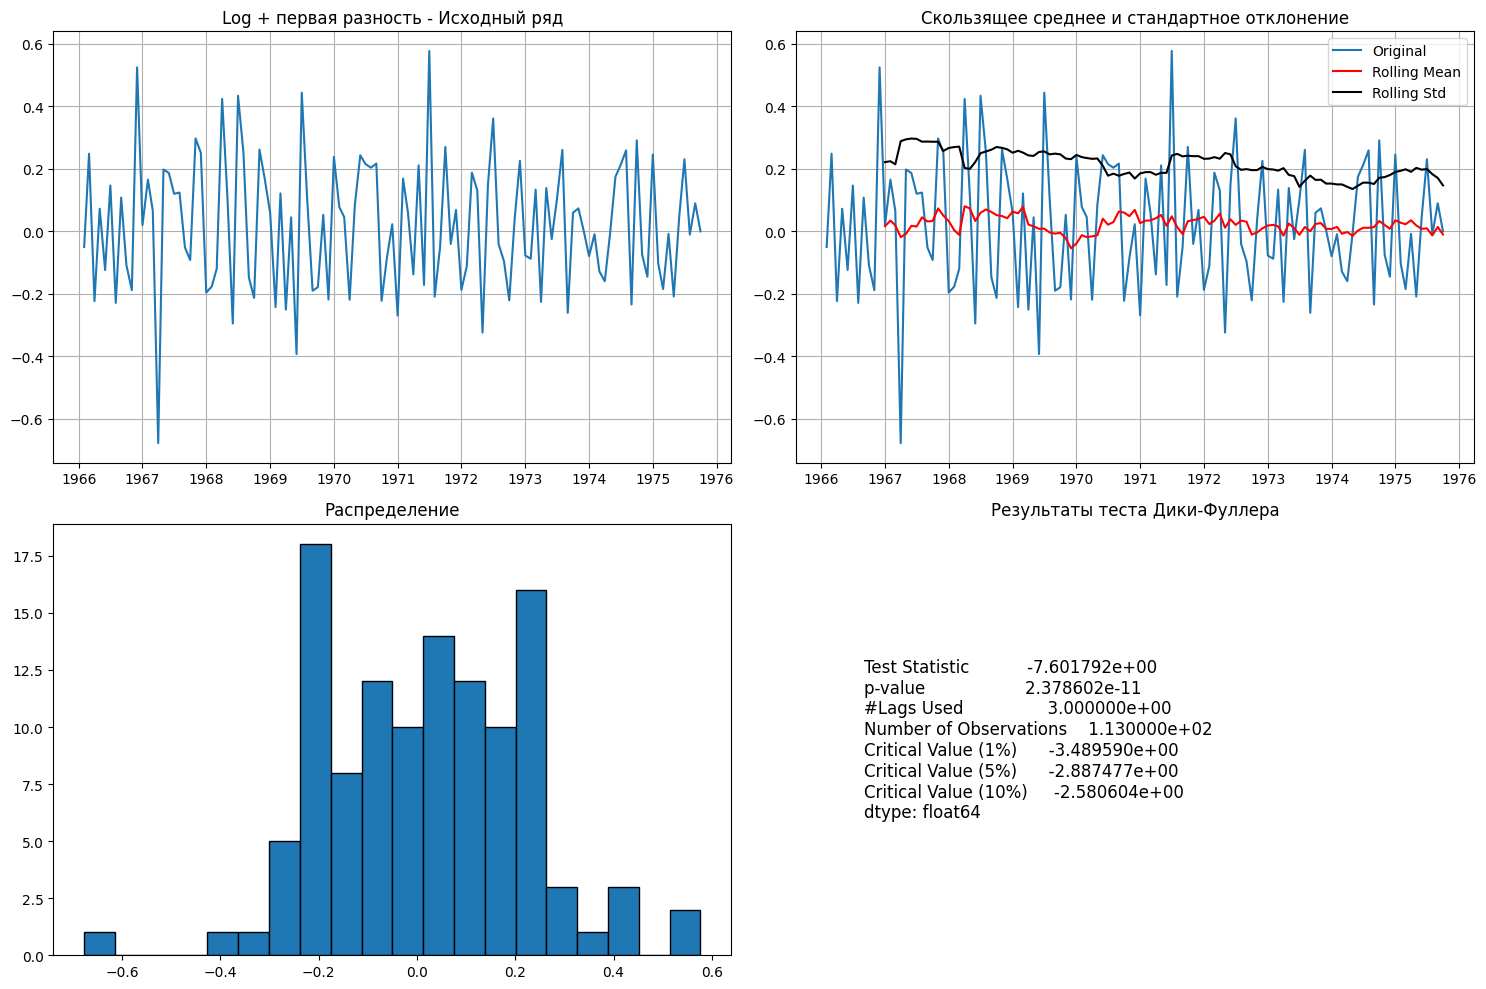


Результаты теста Дики-Фуллера:
Test Statistic           -7.601792e+00
p-value                   2.378602e-11
#Lags Used                3.000000e+00
Number of Observations    1.130000e+02
Critical Value (1%)      -3.489590e+00
Critical Value (5%)      -2.887477e+00
Critical Value (10%)     -2.580604e+00
dtype: float64

✅ p-value (0.0000) <= 0.05 - Ряд стационарен


2.3786024417437596e-11

In [29]:
data_monthly_boston['Count_log'] = np.log(data_monthly_boston['Count'])
data_monthly_boston['Count_log_diff'] = data_monthly_boston['Count_log'].diff()
check_stationarity(data_monthly_boston['Count_log_diff'], 'Log + первая разность')

In [32]:
international_airline = pd.read_csv('/home/slava/Documents/netology_ML/Временные ряды/1._Лекция_tsml/Series/international-airline-passengers.csv')
international_airline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   144 non-null    object
 1   Count   144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [33]:
international_airline.describe()

,Count
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [34]:
international_airline['Month'] = pd.to_datetime(international_airline['Month'])
international_airline.set_index('Month', inplace=True)
international_airline.sort_index(inplace=True)

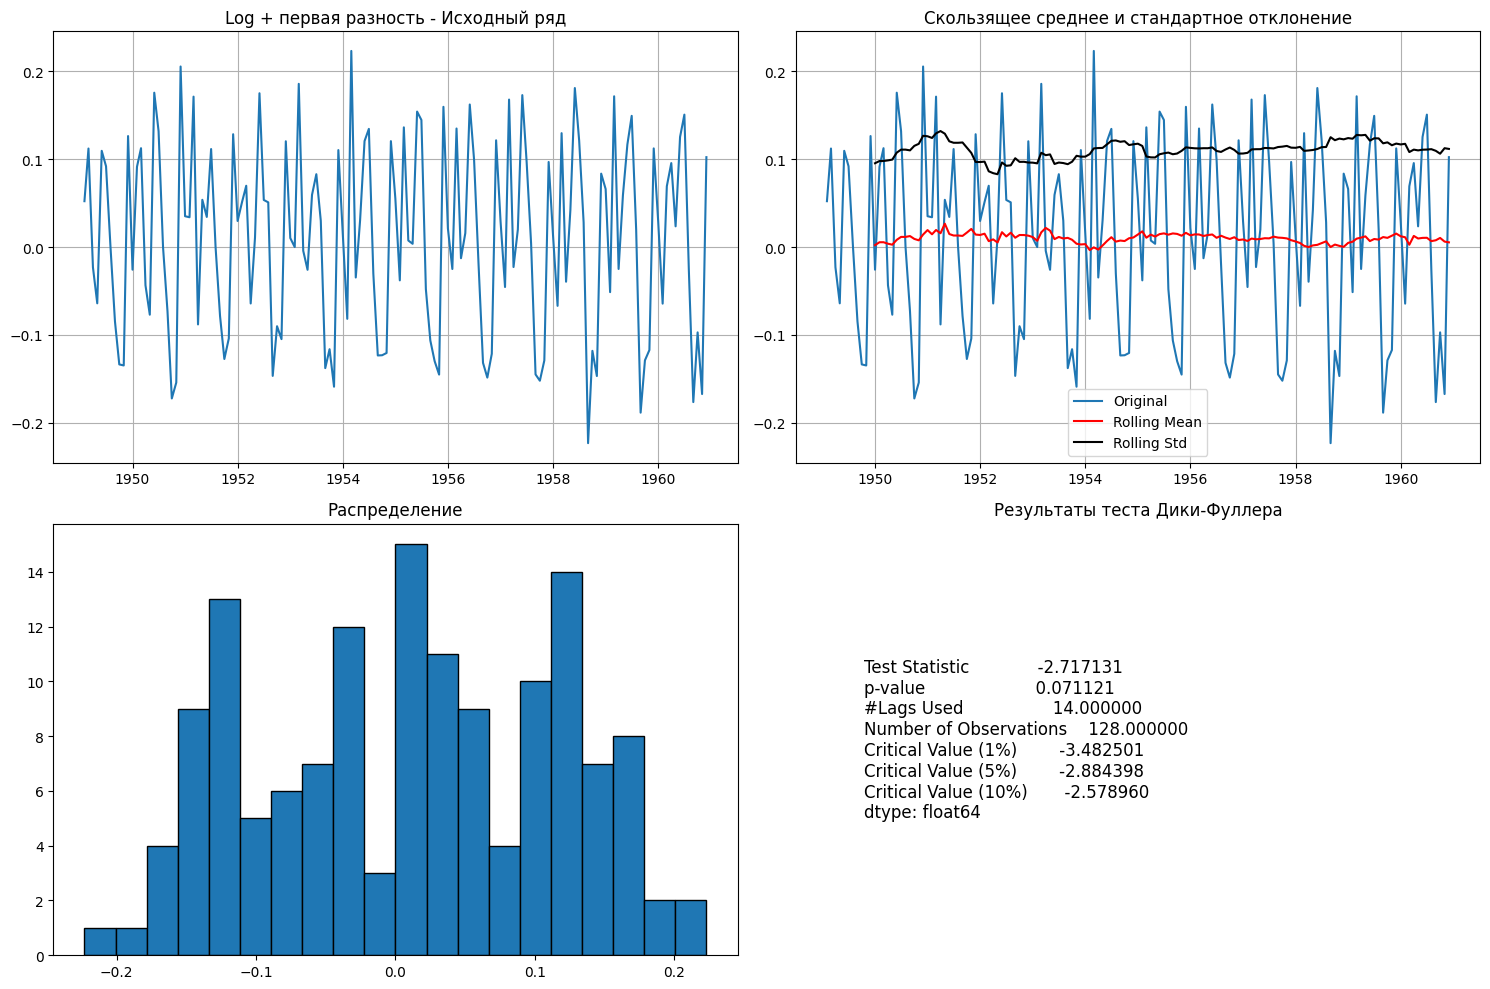


Результаты теста Дики-Фуллера:
Test Statistic             -2.717131
p-value                     0.071121
#Lags Used                 14.000000
Number of Observations    128.000000
Critical Value (1%)        -3.482501
Critical Value (5%)        -2.884398
Critical Value (10%)       -2.578960
dtype: float64

❌ p-value (0.0711) > 0.05 - Ряд НЕ стационарен


0.07112054815086184

In [37]:
international_airline['Count_log'] = np.log(international_airline['Count'])
international_airline['Count_log_diff'] = international_airline['Count_log'].diff()
check_stationarity(international_airline['Count_log_diff'], 'Log + первая разность')

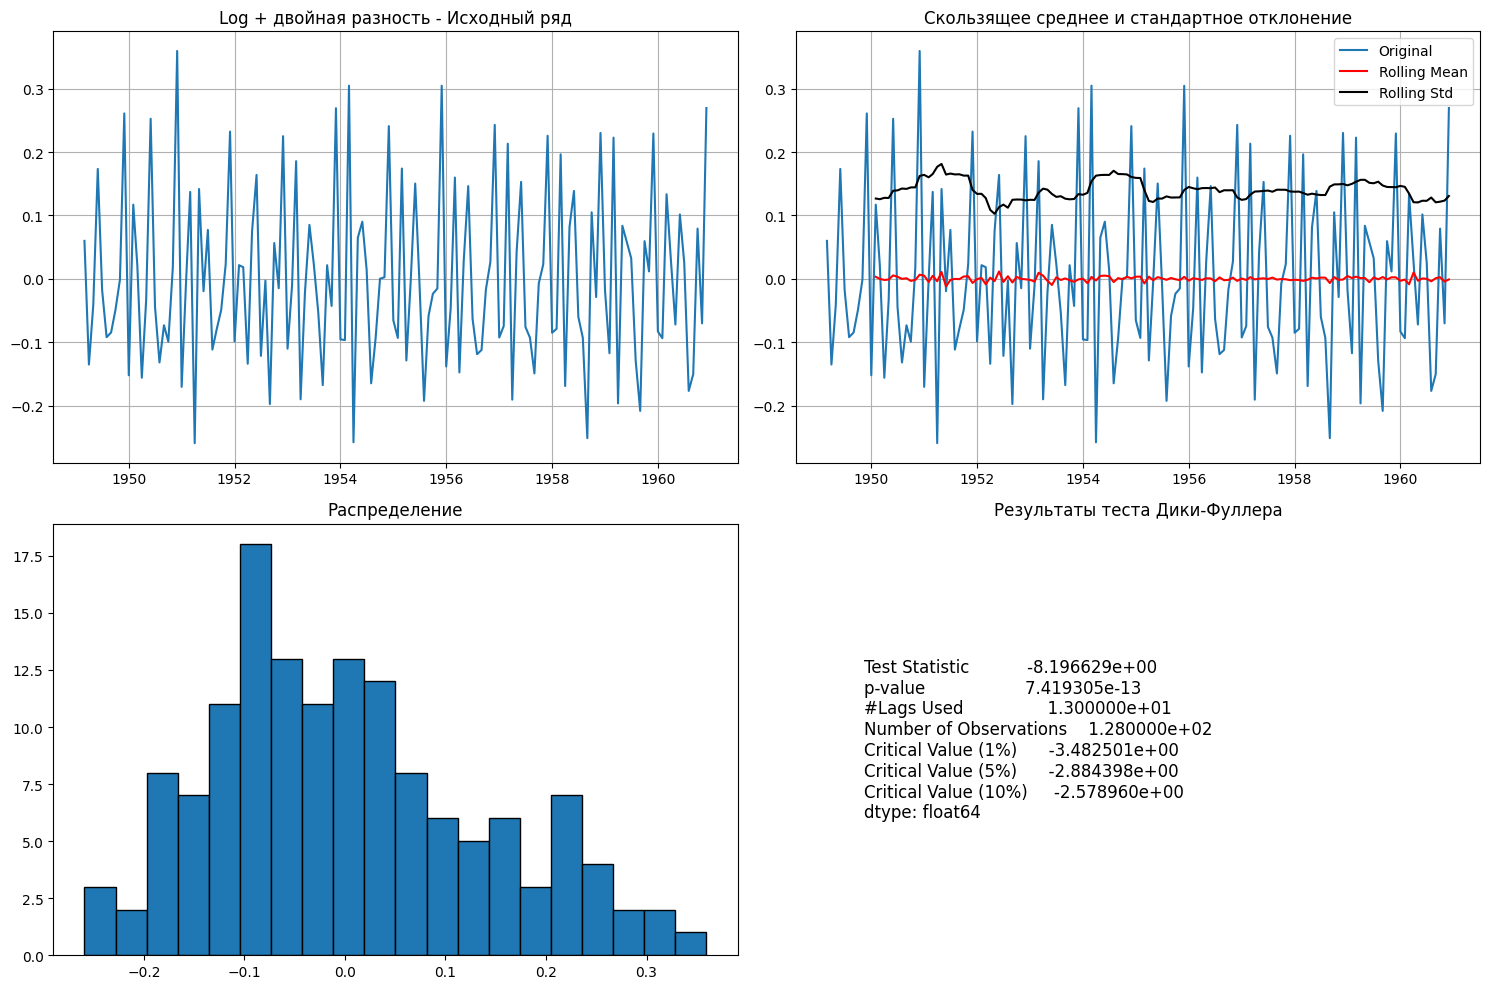


Результаты теста Дики-Фуллера:
Test Statistic           -8.196629e+00
p-value                   7.419305e-13
#Lags Used                1.300000e+01
Number of Observations    1.280000e+02
Critical Value (1%)      -3.482501e+00
Critical Value (5%)      -2.884398e+00
Critical Value (10%)     -2.578960e+00
dtype: float64

✅ p-value (0.0000) <= 0.05 - Ряд стационарен


7.419304549376186e-13

In [38]:
international_airline['Count_log_diff2'] = international_airline['Count_log'].diff().diff()
check_stationarity(international_airline['Count_log_diff2'], 'Log + двойная разность')

In [39]:
mean_monthly_air_temperature = pd.read_csv('/home/slava/Documents/netology_ML/Временные ряды/1._Лекция_tsml/Series/mean-monthly-air-temperature-deg.csv')
mean_monthly_air_temperature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Month   240 non-null    object 
 1   Deg     240 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.9+ KB


In [40]:
mean_monthly_air_temperature.describe()

,Deg
count,240.000000
mean,49.041250
std,8.569705
min,31.300000
25%,41.550000
50%,47.350000
75%,57.000000
max,66.500000


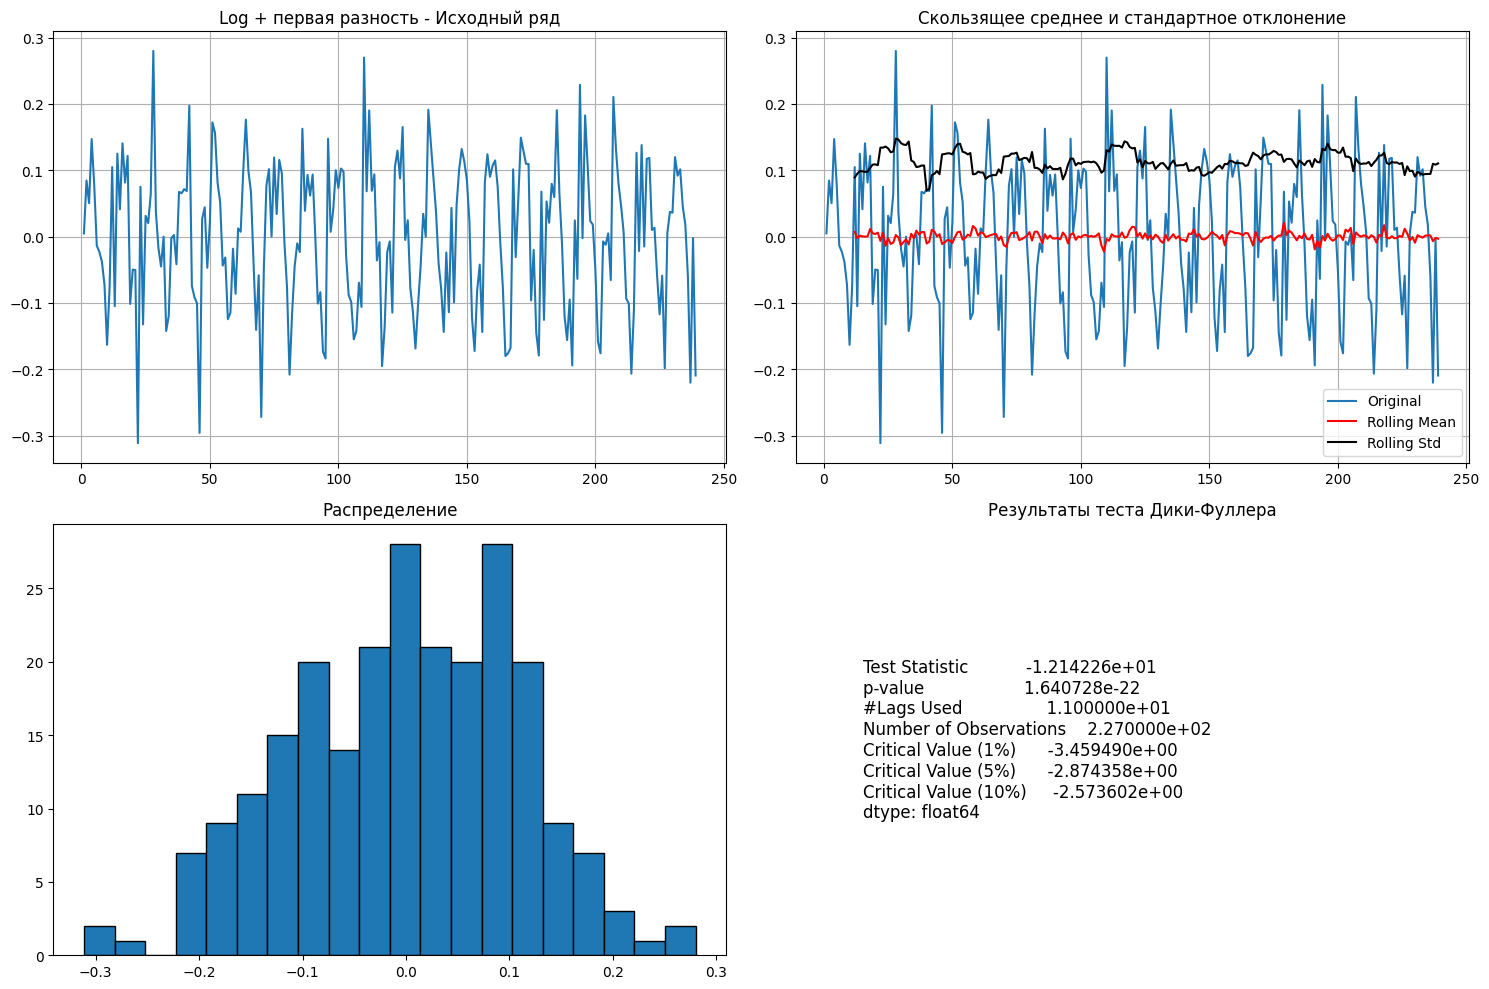


Результаты теста Дики-Фуллера:
Test Statistic           -1.214226e+01
p-value                   1.640728e-22
#Lags Used                1.100000e+01
Number of Observations    2.270000e+02
Critical Value (1%)      -3.459490e+00
Critical Value (5%)      -2.874358e+00
Critical Value (10%)     -2.573602e+00
dtype: float64

✅ p-value (0.0000) <= 0.05 - Ряд стационарен


1.6407281304676633e-22

In [42]:
mean_monthly_air_temperature['Deg_log'] = np.log(mean_monthly_air_temperature['Deg'])
mean_monthly_air_temperature['Deg_log_diff'] = mean_monthly_air_temperature['Deg_log'].diff()
check_stationarity(mean_monthly_air_temperature['Deg_log_diff'], 'Log + первая разность')

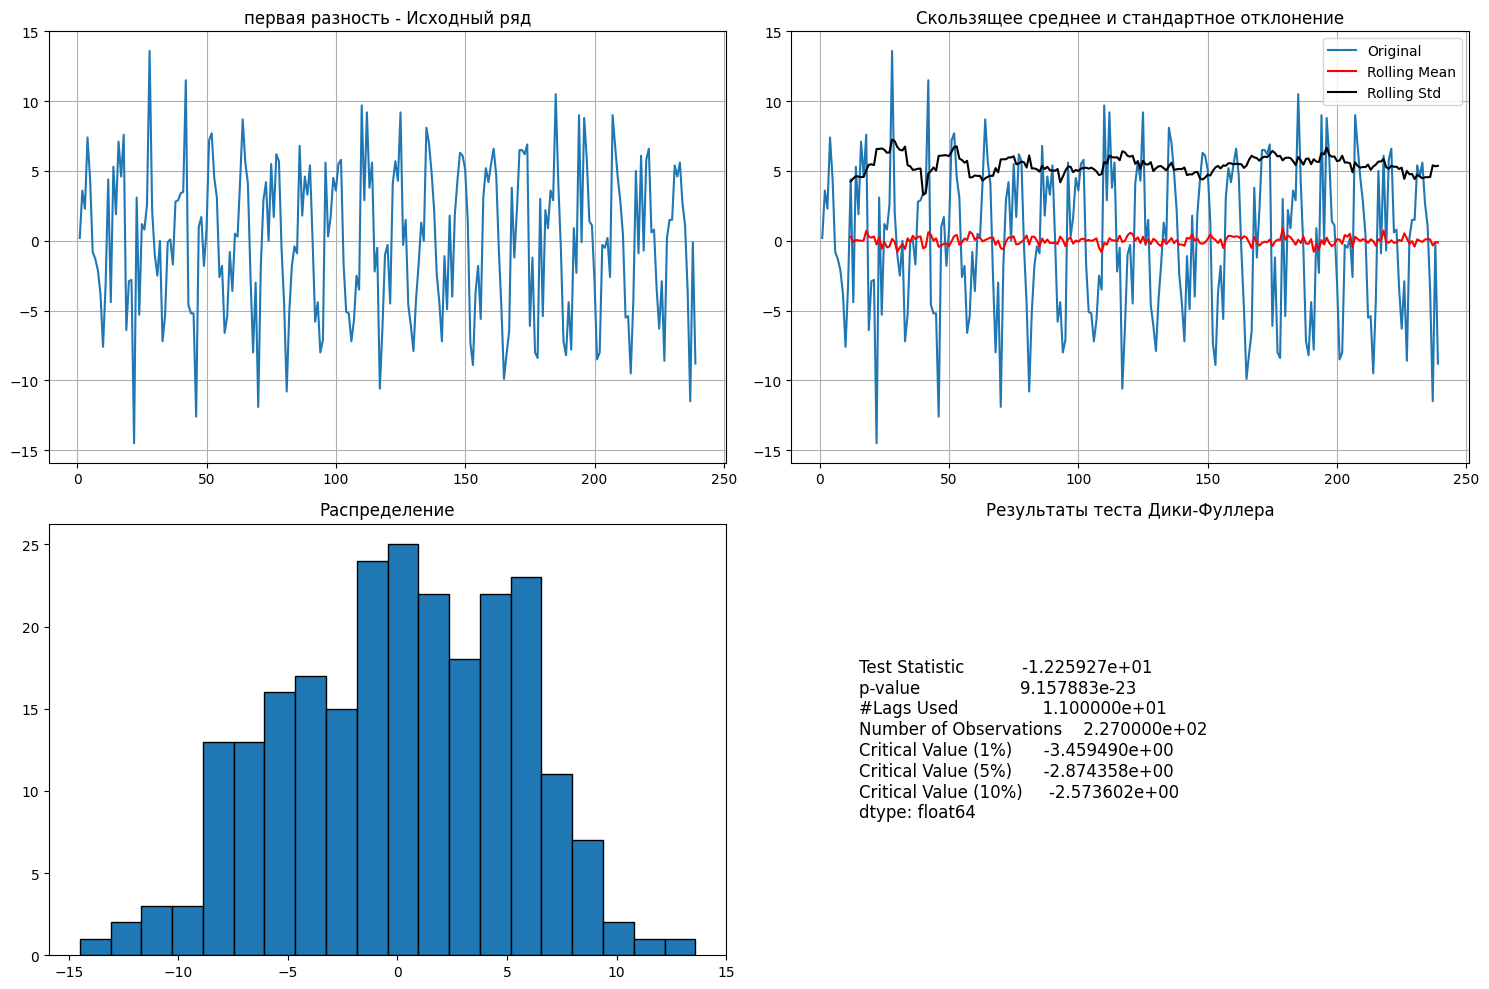


Результаты теста Дики-Фуллера:
Test Statistic           -1.225927e+01
p-value                   9.157883e-23
#Lags Used                1.100000e+01
Number of Observations    2.270000e+02
Critical Value (1%)      -3.459490e+00
Critical Value (5%)      -2.874358e+00
Critical Value (10%)     -2.573602e+00
dtype: float64

✅ p-value (0.0000) <= 0.05 - Ряд стационарен


9.157883248646586e-23

In [43]:
mean_monthly_air_temperature['Deg_diff'] = mean_monthly_air_temperature['Deg'].diff()
check_stationarity(mean_monthly_air_temperature['Deg_diff'], 'первая разность')

In [44]:
weekly_closings = pd.read_csv('/home/slava/Documents/netology_ML/Временные ряды/1._Лекция_tsml/Series/weekly-closings-of-the-dowjones-.csv')
weekly_closings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Week    162 non-null    object 
 1   Close   162 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.7+ KB


In [45]:
weekly_closings.describe()

,Close
count,162.000000
mean,907.484753
std,60.599919
min,752.580000
25%,857.170000
50%,908.645000
75%,951.572500
max,1047.490000


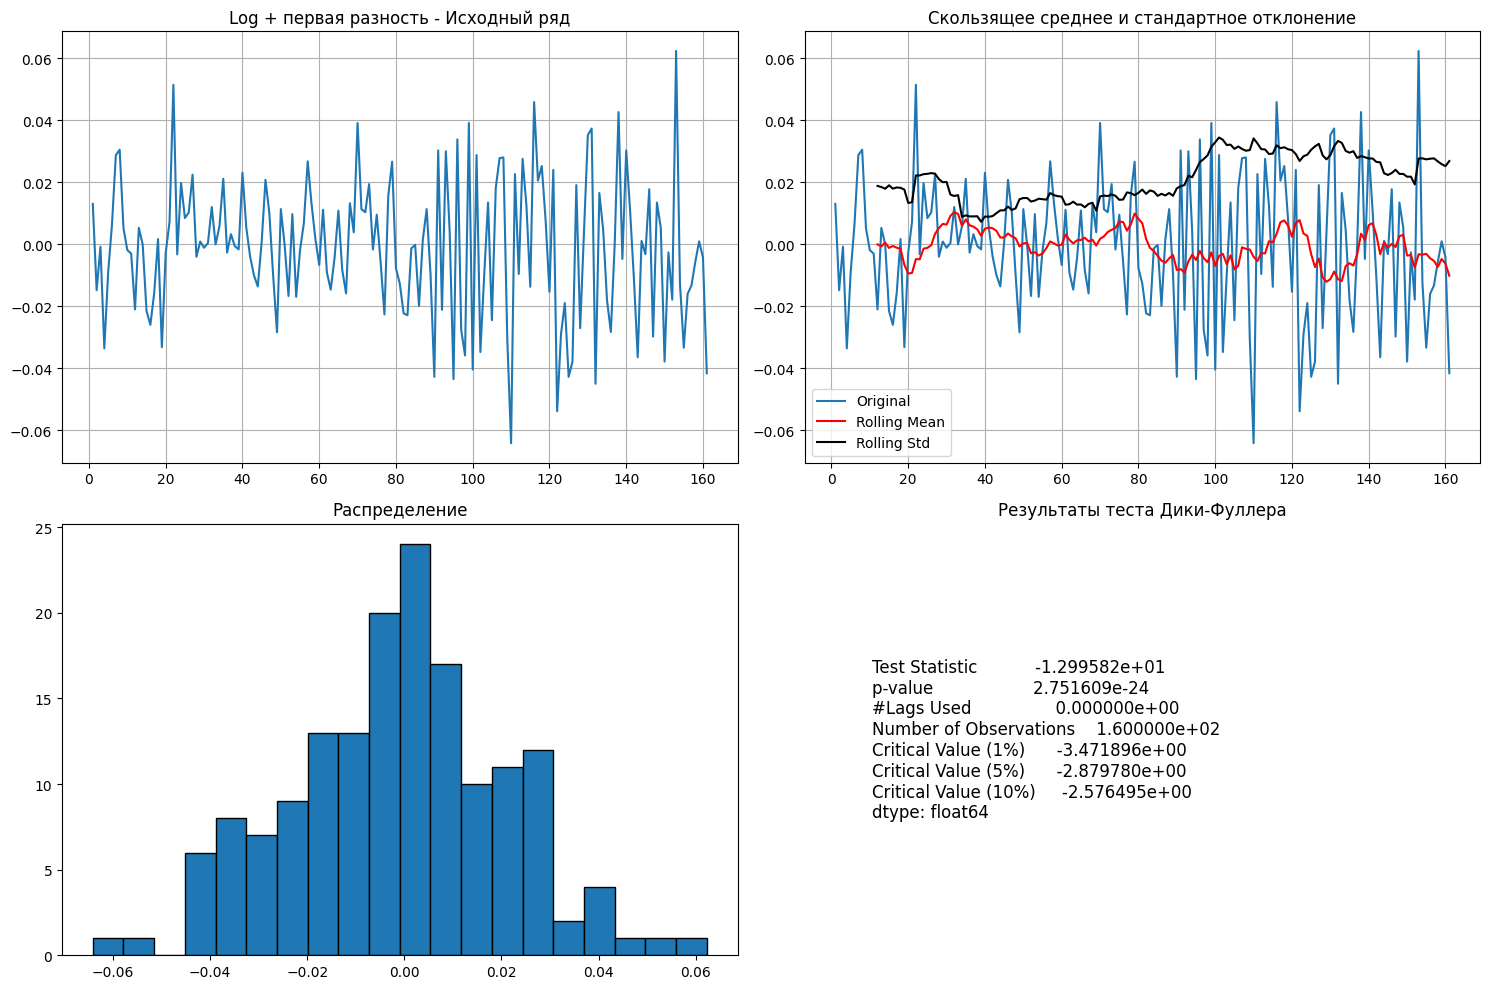


Результаты теста Дики-Фуллера:
Test Statistic           -1.299582e+01
p-value                   2.751609e-24
#Lags Used                0.000000e+00
Number of Observations    1.600000e+02
Critical Value (1%)      -3.471896e+00
Critical Value (5%)      -2.879780e+00
Critical Value (10%)     -2.576495e+00
dtype: float64

✅ p-value (0.0000) <= 0.05 - Ряд стационарен


2.7516091322913448e-24

In [47]:
weekly_closings['Close_log'] = np.log(weekly_closings['Close'])
weekly_closings['Close_log_diff'] = weekly_closings['Close_log'].diff()
check_stationarity(weekly_closings['Close_log_diff'], 'Log + первая разность')

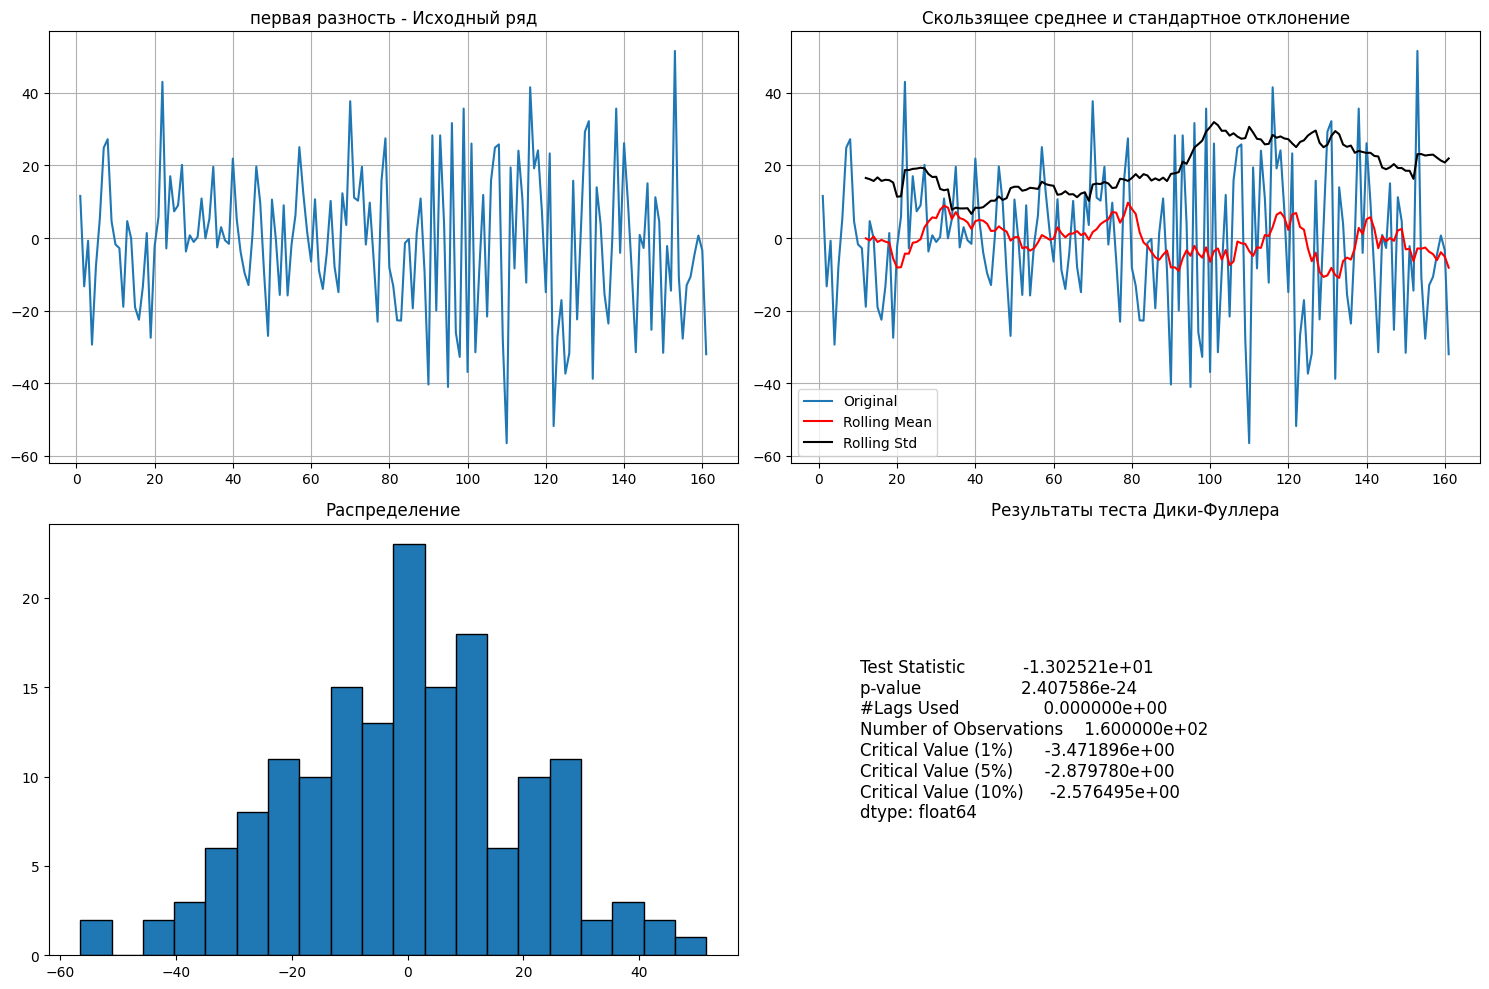


Результаты теста Дики-Фуллера:
Test Statistic           -1.302521e+01
p-value                   2.407586e-24
#Lags Used                0.000000e+00
Number of Observations    1.600000e+02
Critical Value (1%)      -3.471896e+00
Critical Value (5%)      -2.879780e+00
Critical Value (10%)     -2.576495e+00
dtype: float64

✅ p-value (0.0000) <= 0.05 - Ряд стационарен


2.4075864037417794e-24

In [48]:
weekly_closings['Close_diff'] = weekly_closings['Close'].diff()
check_stationarity(weekly_closings['Close_diff'], 'первая разность')

In [49]:
daily_total_female_births = pd.read_csv('/home/slava/Documents/netology_ML/Временные ряды/1._Лекция_tsml/Series/daily-total-female-births-in-cal.csv')
daily_total_female_births.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    365 non-null    object
 1   Count   365 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 5.8+ KB


In [50]:
daily_total_female_births.describe()

,Count
count,365.000000
mean,41.980822
std,7.348257
min,23.000000
25%,37.000000
50%,42.000000
75%,46.000000
max,73.000000


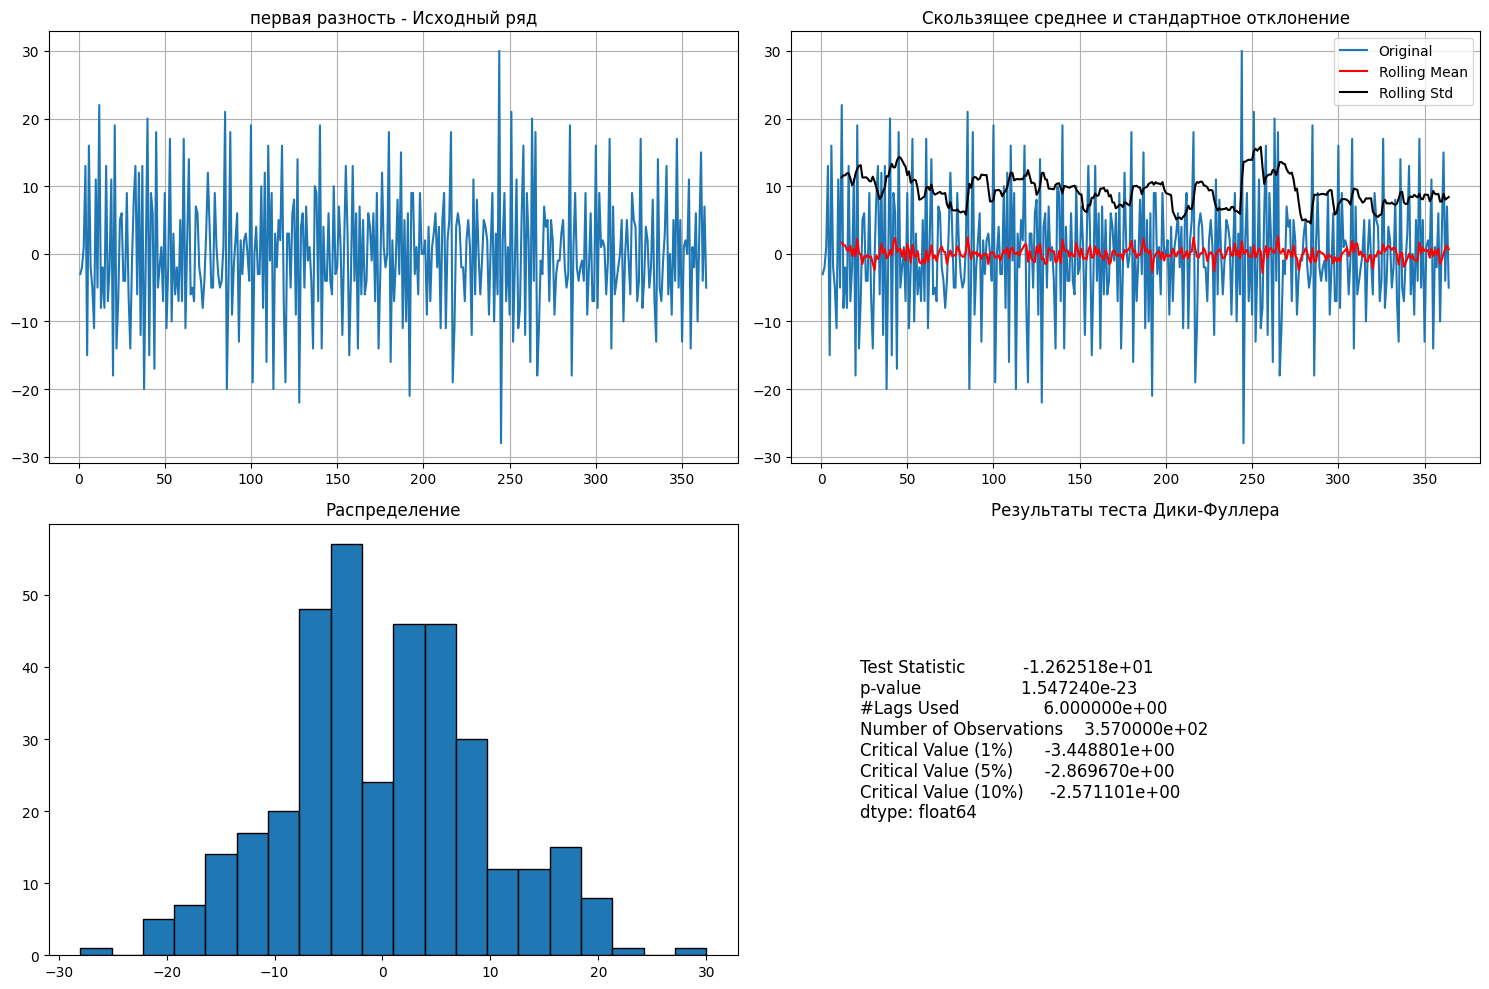


Результаты теста Дики-Фуллера:
Test Statistic           -1.262518e+01
p-value                   1.547240e-23
#Lags Used                6.000000e+00
Number of Observations    3.570000e+02
Critical Value (1%)      -3.448801e+00
Critical Value (5%)      -2.869670e+00
Critical Value (10%)     -2.571101e+00
dtype: float64

✅ p-value (0.0000) <= 0.05 - Ряд стационарен


1.5472400091968453e-23

In [51]:
daily_total_female_births['Count_diff'] = daily_total_female_births['Count'].diff()
check_stationarity(daily_total_female_births['Count_diff'], 'первая разность')

## Выводы
Сделать данные стационарными можно разными способами. Но на 6 dataset мы увидели, что отлично работает полечение разности. А там где её не достаточно, то взяв логорифм мы гарантировано получаем сходимый ряд.
Да, во многих data set есть сезонность. Но и без ее учета можно добиться стационарности.